# 한글 폰트 깨짐 확인 및 helper_plot_hangul 적용 테스트

helper_plot_hangul 모듈 적용 전후의 한글 폰트 출력 상태를 비교합니다.

## 1. 라이브러리 임포트 및 샘플 데이터 준비

In [1]:
import helper_plot_hangul
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import numpy as np
import pandas as pd

# 샘플 데이터 (한글 레이블 포함)
categories = ["사과", "바나나", "포도", "딸기", "오렌지"]
values = [42, 35, 28, 51, 39]

months = ["1월", "2월", "3월", "4월", "5월", "6월"]
sales_a = [120, 135, 148, 162, 178, 195]
sales_b = [90, 105, 98, 115, 130, 142]

df = pd.DataFrame({
    "과일": categories * 3,
    "판매량": values + [v + 10 for v in values] + [v - 5 for v in values],
    "분기": ["1분기"] * 5 + ["2분기"] * 5 + ["3분기"] * 5,
})

print("현재 폰트 패밀리:", matplotlib.rcParams["font.family"])

현재 폰트 패밀리: ['NanumGothic']


## 2. 한글 깨지는 기본 Matplotlib 그래프

폰트 설정 없이 그리면 한글이 □□□ 또는 물음표로 깨집니다.

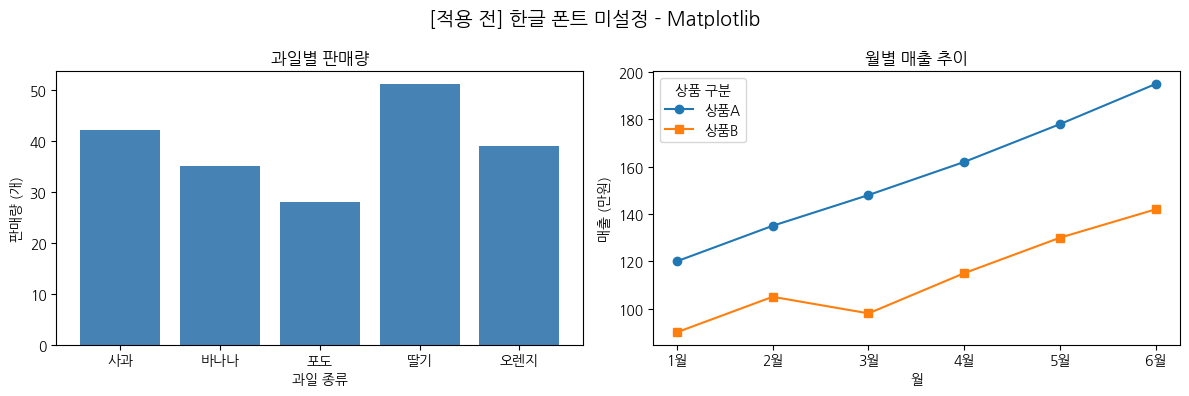

In [2]:
# --- 적용 전: 한글 깨짐 확인 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("[적용 전] 한글 폰트 미설정 - Matplotlib", fontsize=14)

# 막대 그래프
axes[0].bar(categories, values, color="steelblue")
axes[0].set_title("과일별 판매량")
axes[0].set_xlabel("과일 종류")
axes[0].set_ylabel("판매량 (개)")

# 꺾은선 그래프
axes[1].plot(months, sales_a, marker="o", label="상품A")
axes[1].plot(months, sales_b, marker="s", label="상품B")
axes[1].set_title("월별 매출 추이")
axes[1].set_xlabel("월")
axes[1].set_ylabel("매출 (만원)")
axes[1].legend(title="상품 구분")

plt.tight_layout()
plt.show()

## 3. 한글 깨지는 Seaborn 그래프 및 테마 적용

`seaborn` 테마를 적용해도 한글 깨짐은 동일하게 발생합니다.

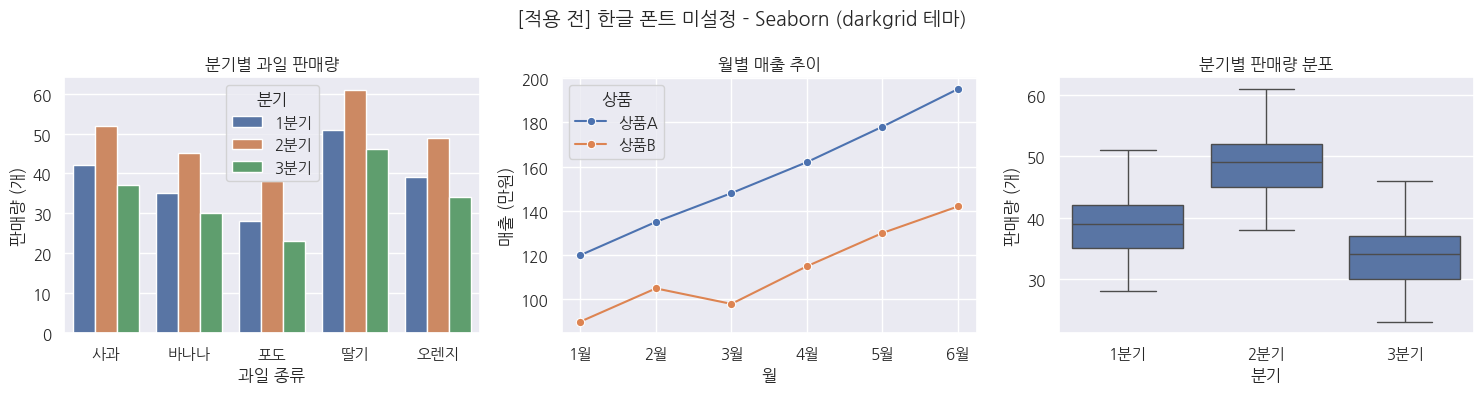

In [3]:
# --- 적용 전: Seaborn 테마 + 한글 깨짐 확인 ---
sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("[적용 전] 한글 폰트 미설정 - Seaborn (darkgrid 테마)", fontsize=14)

# barplot
sns.barplot(data=df, x="과일", y="판매량", hue="분기", ax=axes[0])
axes[0].set_title("분기별 과일 판매량")
axes[0].set_xlabel("과일 종류")
axes[0].set_ylabel("판매량 (개)")

# lineplot
df_month = pd.DataFrame({"월": months * 2, "매출": sales_a + sales_b, "상품": ["상품A"] * 6 + ["상품B"] * 6})
sns.lineplot(data=df_month, x="월", y="매출", hue="상품", marker="o", ax=axes[1])
axes[1].set_title("월별 매출 추이")
axes[1].set_xlabel("월")
axes[1].set_ylabel("매출 (만원)")

# boxplot
sns.boxplot(data=df, x="분기", y="판매량", ax=axes[2])
axes[2].set_title("분기별 판매량 분포")
axes[2].set_xlabel("분기")
axes[2].set_ylabel("판매량 (개)")

plt.tight_layout()
plt.show()

## 4. helper_plot_hangul 모듈 임포트

`import helper_plot_hangul` 실행 시 한글 폰트가 자동으로 적용됩니다.

In [4]:
# import helper_plot_hangul

print("적용된 폰트 패밀리:", matplotlib.rcParams["font.family"])
print("unicode_minus:", matplotlib.rcParams["axes.unicode_minus"])

적용된 폰트 패밀리: ['NanumGothic']
unicode_minus: False


## 5. 한글 정상 출력 Matplotlib 그래프 확인

동일한 그래프를 다시 그려 한글이 정상 출력되는지 확인합니다.

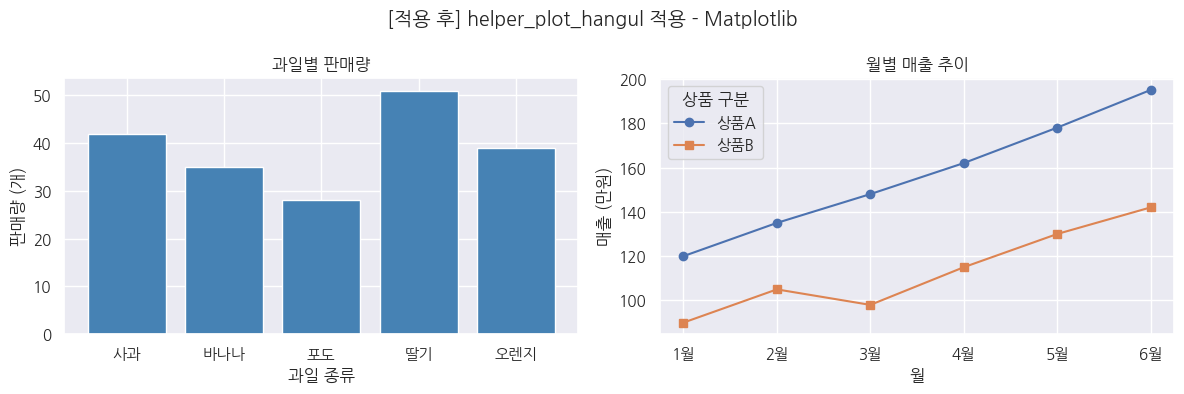

In [5]:
# --- 적용 후: 한글 정상 출력 확인 - Matplotlib ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("[적용 후] helper_plot_hangul 적용 - Matplotlib", fontsize=14)

# 막대 그래프
axes[0].bar(categories, values, color="steelblue")
axes[0].set_title("과일별 판매량")
axes[0].set_xlabel("과일 종류")
axes[0].set_ylabel("판매량 (개)")

# 꺾은선 그래프
axes[1].plot(months, sales_a, marker="o", label="상품A")
axes[1].plot(months, sales_b, marker="s", label="상품B")
axes[1].set_title("월별 매출 추이")
axes[1].set_xlabel("월")
axes[1].set_ylabel("매출 (만원)")
axes[1].legend(title="상품 구분")

plt.tight_layout()
plt.show()

## 6. 한글 정상 출력 Seaborn 기본 그래프 확인 (테마 없음)

Seaborn 테마 적용 전, 기본 상태에서 한글이 정상 출력되는지 먼저 확인합니다.

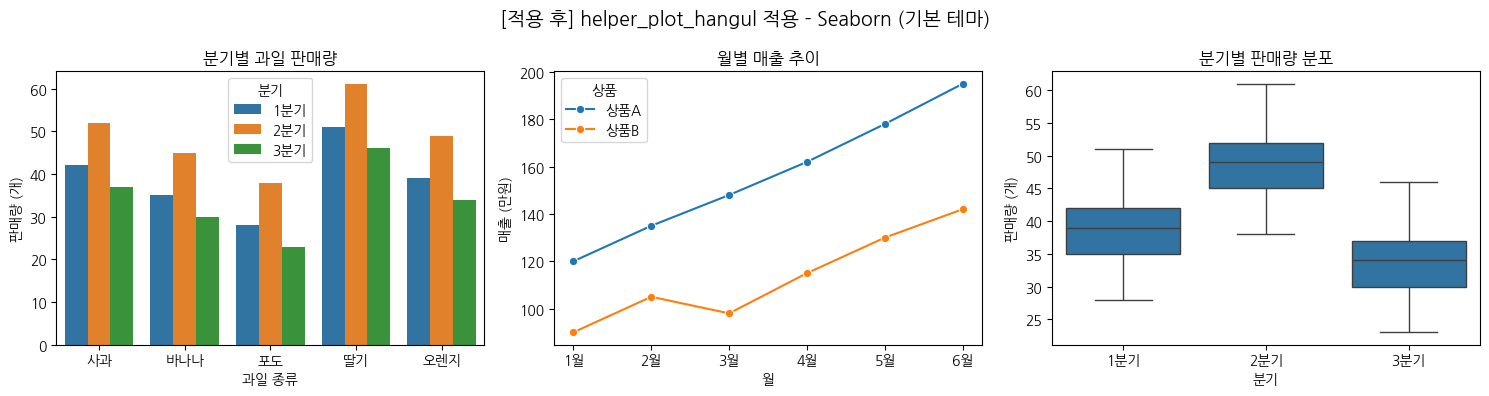

In [6]:
# --- 적용 후: Seaborn 기본 테마 (테마 없음) + 한글 정상 출력 확인 ---
# sns.reset_defaults() 후 자동으로 한글 폰트 재적용됨 (helper_plot_hangul이 내부 패치)
sns.reset_defaults()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("[적용 후] helper_plot_hangul 적용 - Seaborn (기본 테마)", fontsize=14)

# barplot
sns.barplot(data=df, x="과일", y="판매량", hue="분기", ax=axes[0])
axes[0].set_title("분기별 과일 판매량")
axes[0].set_xlabel("과일 종류")
axes[0].set_ylabel("판매량 (개)")

# lineplot
sns.lineplot(data=df_month, x="월", y="매출", hue="상품", marker="o", ax=axes[1])
axes[1].set_title("월별 매출 추이")
axes[1].set_xlabel("월")
axes[1].set_ylabel("매출 (만원)")

# boxplot
sns.boxplot(data=df, x="분기", y="판매량", ax=axes[2])
axes[2].set_title("분기별 판매량 분포")
axes[2].set_xlabel("분기")
axes[2].set_ylabel("판매량 (개)")

plt.tight_layout()
plt.show()

## 7. 한글 정상 출력 Seaborn 그래프 및 테마 확인

동일한 Seaborn 테마와 그래프로 한글 정상 출력을 최종 확인합니다.

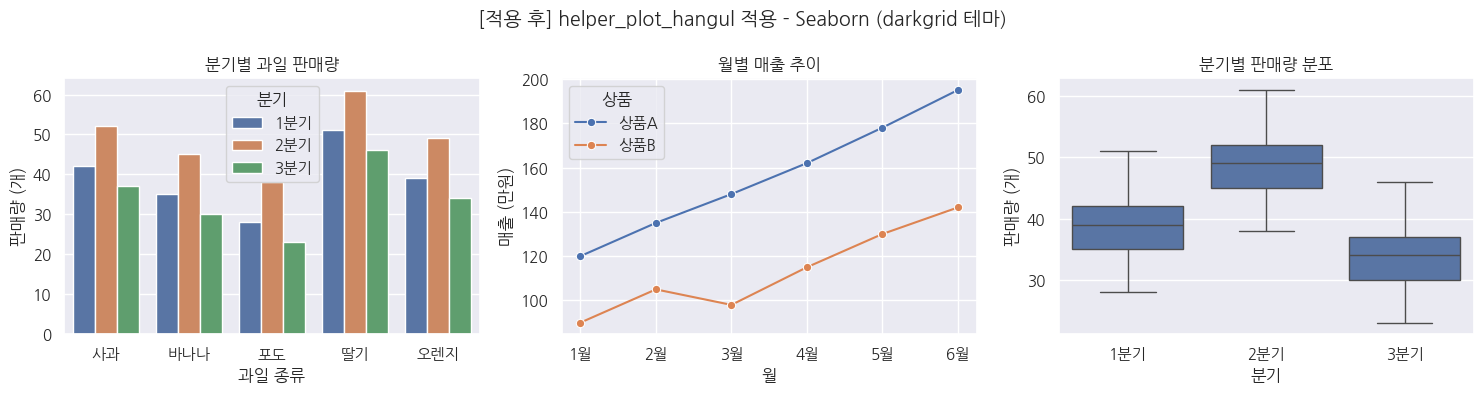

In [7]:
# --- 적용 후: Seaborn 테마 + 한글 정상 출력 확인 ---
# sns.set_theme() 후 자동으로 한글 폰트 재적용됨 (helper_plot_hangul이 내부 패치)
sns.set_theme(style="darkgrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("[적용 후] helper_plot_hangul 적용 - Seaborn (darkgrid 테마)", fontsize=14)

# barplot
sns.barplot(data=df, x="과일", y="판매량", hue="분기", ax=axes[0])
axes[0].set_title("분기별 과일 판매량")
axes[0].set_xlabel("과일 종류")
axes[0].set_ylabel("판매량 (개)")

# lineplot
sns.lineplot(data=df_month, x="월", y="매출", hue="상품", marker="o", ax=axes[1])
axes[1].set_title("월별 매출 추이")
axes[1].set_xlabel("월")
axes[1].set_ylabel("매출 (만원)")

# boxplot
sns.boxplot(data=df, x="분기", y="판매량", ax=axes[2])
axes[2].set_title("분기별 판매량 분포")
axes[2].set_xlabel("분기")
axes[2].set_ylabel("판매량 (개)")

plt.tight_layout()
plt.show()